# Random Forest Regression

This notebook trains and evaluates a Random Forest Regression model for bike share demand prediction.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
def load_data(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(file_path)
    return df


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.dropna().copy()
    return df


def split_data(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    split_idx = int(len(df) * 0.8)
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    return train_df, test_df


def prepare_features(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    X = df.drop(columns=["trips"]).copy()
    y = df["trips"].copy()

    bool_cols = X.select_dtypes(include=["bool"]).columns
    if len(bool_cols) > 0:
        X[bool_cols] = X[bool_cols].astype(int)

    return X, y


def train_random_forest_regression(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    n_estimators: int = 200,
    max_depth: int | None = 20,
    min_samples_split: int = 5,
    min_samples_leaf: int = 2,
    random_state: int = 42,
    n_jobs: int = -1,
) -> RandomForestRegressor:
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state,
        n_jobs=n_jobs,
    )
    model.fit(X_train, y_train)
    return model


def evaluate_model(model: RandomForestRegressor, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "predictions": y_pred,
    }


def get_feature_importance(model: RandomForestRegressor, feature_names: list[str]) -> pd.DataFrame:
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_,
    })
    importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)
    return importance_df


In [5]:
file_path = "../data/processed/final_dataset.csv"

df = load_data(file_path)
df = clean_data(df)
train_df, test_df = split_data(df)
X_train, y_train = prepare_features(train_df)
X_test, y_test = prepare_features(test_df)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
X_train.head()


Train shape: (929542, 9)
Test shape: (232386, 9)


,station_id,hour,weekday,month,lag_1,lag_24,member_ratio,is_weekend,historical_avg_demand
24,7000,5,1,1,1.0,10.0,0.500000,0,49.68652
25,7000,6,1,1,4.0,6.0,0.052632,0,49.68652
26,7000,7,1,1,19.0,16.0,0.217391,0,49.68652
27,7000,8,1,1,23.0,19.0,0.211268,0,49.68652
28,7000,9,1,1,71.0,42.0,0.285714,0,49.68652


In [6]:
model = train_random_forest_regression(X_train, y_train)
results = evaluate_model(model, X_test, y_test)

print("Random Forest Regression Results")
print(f"MAE:  {results['MAE']:.4f}")
print(f"MSE:  {results['MSE']:.4f}")
print(f"RMSE: {results['RMSE']:.4f}")
print(f"R2:   {results['R2']:.4f}")


Random Forest Regression Results
MAE:  2.7555
MSE:  26.4067
RMSE: 5.1387
R2:   0.8524


In [7]:
importance_df = get_feature_importance(model, X_train.columns.tolist())
importance_df


,feature,importance
0,lag_1,0.825467
1,hour,0.063084
2,lag_24,0.034701
3,member_ratio,0.024943
4,historical_avg_demand,0.019095
5,weekday,0.011630
6,station_id,0.011164
7,month,0.007253
8,is_weekend,0.002663


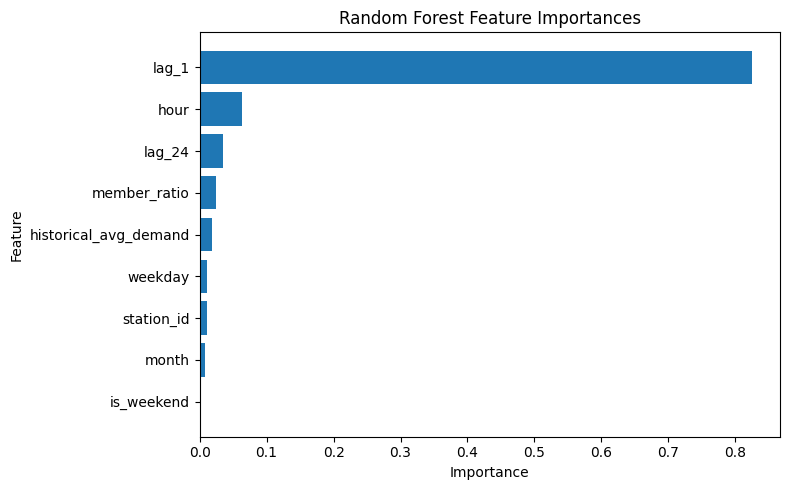

In [8]:
plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [9]:
y_pred = results["predictions"]

comparison_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred,
})
comparison_df.head(10)


,actual,predicted
0,3,6.005744
1,13,13.387423
2,11,21.081087
3,12,13.114435
4,7,15.325031
5,12,11.789657
6,14,9.667785
7,15,10.367679
8,13,17.784527
9,27,15.515140


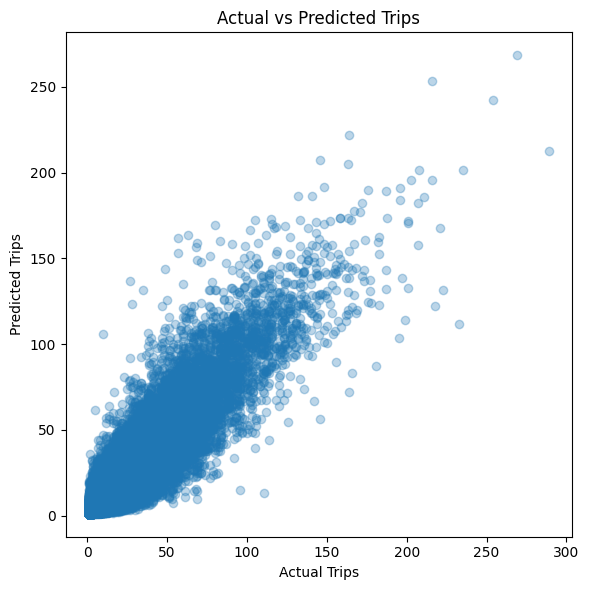

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Trips")
plt.ylabel("Predicted Trips")
plt.title("Actual vs Predicted Trips")
plt.tight_layout()
plt.show()
